# Retinopathy Disease Classification with EfficientNet

Classification system for fundus images using EfficientNet-B1 architecture with balanced training approach.

In [1]:
# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
import timm

# Image processing
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 14.7 GB


In [2]:
# Configuration
class Config:
    DATA_PATH = "/kaggle/input/retinopathy-dataset/Retinopathy-Dataset"
    MODEL_NAME = 'efficientnet_b1'
    IMG_SIZE = 288
    BATCH_SIZE = 32 if device.type == 'cuda' else 8
    NUM_EPOCHS = 40
    NUM_WORKERS = 4 if device.type == 'cuda' else 0
    LEARNING_RATE = 3e-5
    DROPOUT_RATE = 0.3
    WEIGHT_DECAY = 1e-4
    
    # Excluded classes for training
    EXCLUDED_CLASSES = {
        "Diabetic Nephropathy", 
        "Optic Disc Cupping", 
        "Optic Disc Pallor", 
        "Tessellation", 
        "Myelinated Nerve Fibers",
        "Vitreous Degeneration",
        "Hypertensive",
        "Hypertensive Retinopathy"
    }

config = Config()

print(f"Model: {config.MODEL_NAME}")
print(f"Image size: {config.IMG_SIZE}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Epochs: {config.NUM_EPOCHS}")
print(f"Learning rate: {config.LEARNING_RATE}")
print(f"Excluded classes: {len(config.EXCLUDED_CLASSES)}")

Model: efficientnet_b1
Image size: 288
Batch size: 32
Epochs: 40
Learning rate: 3e-05
Excluded classes: 8


In [3]:
# Data loading
def load_dataset(data_path, excluded_classes):
    image_paths = []
    labels = []
    
    # Get all class directories
    class_dirs = [d for d in os.listdir(data_path) 
                  if os.path.isdir(os.path.join(data_path, d)) and not d.startswith('.')]
    
    # Filter out excluded classes
    class_dirs = [d for d in class_dirs if d not in excluded_classes]
    
    print(f"Found {len(class_dirs)} classes after exclusion")
    
    for class_name in class_dirs:
        class_path = os.path.join(data_path, class_name)
        
        # Get image files
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            image_files.extend(Path(class_path).glob(ext))
        
        # Validate images
        valid_images = []
        for img_path in image_files:
            try:
                test_img = cv2.imread(str(img_path))
                if test_img is not None:
                    valid_images.append(img_path)
            except:
                continue
        
        print(f"{class_name}: {len(valid_images)} images")
        
        for img_path in valid_images:
            image_paths.append(str(img_path))
            labels.append(class_name)
    
    df = pd.DataFrame({
        'image_path': image_paths,
        'class': labels
    })
    
    return df, sorted(class_dirs)

# Load data
df, classes = load_dataset(config.DATA_PATH, config.EXCLUDED_CLASSES)
print(f"Total images: {len(df)}")
print(f"Classes: {len(classes)}")

# Create label mapping
label_to_idx = {label: idx for idx, label in enumerate(classes)}
df['label'] = df['class'].map(label_to_idx)

# Split data
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

Found 19 classes after exclusion
Macular Scar: 621 images
Pterygium: 204 images
Disc Edema: 604 images
Branch Retinal Vein Occlusion: 119 images
Central Serous Chorioretinopathy: 606 images
Drusen: 736 images
Glaucoma: 619 images
Normal: 669 images
Retinal Detachment: 608 images
Diabetic Retinopathy (Severate): 616 images
Age Macular Degeneration: 622 images
Cataract: 599 images
Diabetic Retinopathy (Mild): 602 images
Retinitis Pigmentosa: 608 images
Macular Epiretinal Membrane: 645 images
Myopia: 778 images
Diabetic Retinopathy (Proliferative): 591 images
Refractive Media Opacity: 104 images
Macular Hole: 523 images
Total images: 10474
Classes: 19
Train: 8379, Val: 2095


In [4]:
# Data transforms
train_transforms = A.Compose([
    A.Resize(config.IMG_SIZE, config.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(config.IMG_SIZE, config.IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Dataset class
class RetinalDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        label = row['label']
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']
        
        return image, label

# Create datasets
train_dataset = RetinalDataset(train_df, train_transforms)
val_dataset = RetinalDataset(val_df, val_transforms)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset: {len(val_dataset)}")

Train dataset: 8379
Val dataset: 2095


In [5]:
# Class weights and data loaders
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Create weighted sampler
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    sampler=sampler,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if device.type == 'cuda' else False,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True if device.type == 'cuda' else False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 261
Val batches: 66


In [6]:
# Model definition
class RetinalClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout_rate):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )
        
        num_features = self.backbone.num_features
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.7),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# Initialize model
model = RetinalClassifier(
    config.MODEL_NAME, 
    len(classes), 
    config.DROPOUT_RATE
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

Model parameters: 7,179,827


In [7]:
# Training setup
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(
    model.parameters(), 
    lr=config.LEARNING_RATE, 
    weight_decay=config.WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.NUM_EPOCHS)
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

print("Training setup complete")

Training setup complete


In [8]:
# Training functions
def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data, target in dataloader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        
        if scaler:
            with torch.cuda.amp.autocast():
                output = model(data)
                loss = criterion(output, target)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    return running_loss / len(dataloader), 100.0 * correct / total

def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    predictions = []
    targets = []
    
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            
            if device.type == 'cuda':
                with torch.cuda.amp.autocast():
                    output = model(data)
                    loss = criterion(output, target)
            else:
                output = model(data)
                loss = criterion(output, target)
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            predictions.extend(predicted.cpu().numpy())
            targets.extend(target.cpu().numpy())
    
    return running_loss / len(dataloader), 100.0 * correct / total, predictions, targets

print("Training functions ready")

Training functions ready


In [9]:
# Training loop
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_val_acc = 0.0

print(f"Training {config.MODEL_NAME} for {config.NUM_EPOCHS} epochs...")

for epoch in range(config.NUM_EPOCHS):
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device, scaler
    )
    val_loss, val_acc, _, _ = validate_epoch(
        model, val_loader, criterion, device
    )
    
    scheduler.step()
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_retinal_classifier.pth')
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

print(f"Training completed. Best validation accuracy: {best_val_acc:.2f}%")

Training efficientnet_b1 for 40 epochs...
Epoch 10: Train Acc: 92.48%, Val Acc: 89.02%
Epoch 20: Train Acc: 97.46%, Val Acc: 89.26%
Epoch 30: Train Acc: 98.24%, Val Acc: 90.69%
Epoch 40: Train Acc: 98.81%, Val Acc: 90.26%
Training completed. Best validation accuracy: 90.84%


In [10]:
# Final evaluation
model.load_state_dict(torch.load('best_retinal_classifier.pth'))
val_loss, val_acc, predictions, targets = validate_epoch(
    model, val_loader, criterion, device
)

print(f"Final Results:")
print(f"Model: {config.MODEL_NAME}")
print(f"Final Validation Accuracy: {val_acc:.2f}%")

# Classification report
print("\nClassification Report:")
print(classification_report(targets, predictions, target_names=classes))

# Save model
model_save_dict = {
    'model_state_dict': model.state_dict(),
    'model_name': config.MODEL_NAME,
    'classes': classes,
    'final_accuracy': val_acc,
    'config': config.__dict__
}

torch.save(model_save_dict, 'retinal_classifier_final.pth')
print("\nModel saved as 'retinal_classifier_final.pth'")

Final Results:
Model: efficientnet_b1
Final Validation Accuracy: 90.84%

Classification Report:
                                      precision    recall  f1-score   support

            Age Macular Degeneration       1.00      1.00      1.00       124
       Branch Retinal Vein Occlusion       1.00      0.71      0.83        24
                            Cataract       1.00      1.00      1.00       120
    Central Serous Chorioretinopathy       0.94      0.99      0.96       121
         Diabetic Retinopathy (Mild)       0.88      0.89      0.89       120
Diabetic Retinopathy (Proliferative)       0.75      0.81      0.78       118
     Diabetic Retinopathy (Severate)       0.82      0.76      0.78       123
                          Disc Edema       1.00      0.98      0.99       121
                              Drusen       0.88      0.82      0.85       147
                            Glaucoma       0.81      0.93      0.86       124
         Macular Epiretinal Membrane       0.

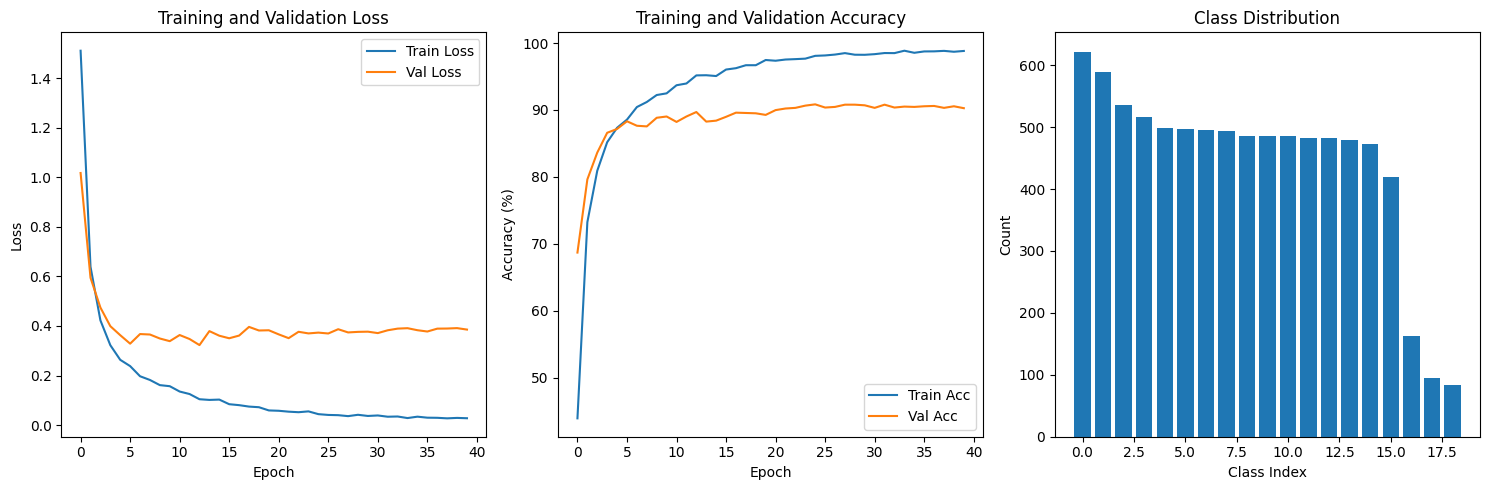

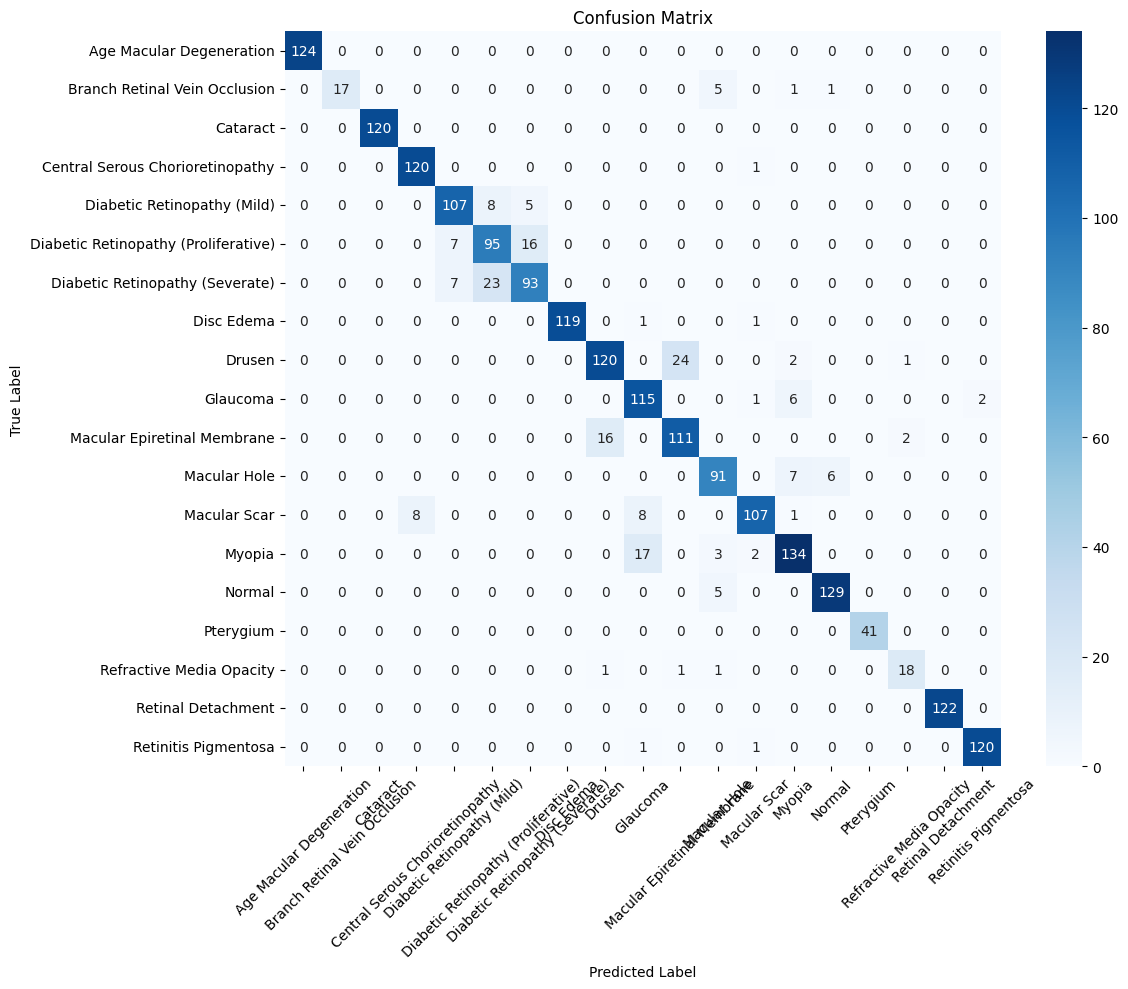

In [11]:
# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Class distribution
plt.subplot(1, 3, 3)
class_counts = train_df['class'].value_counts()
plt.bar(range(len(class_counts)), class_counts.values)
plt.title('Class Distribution')
plt.xlabel('Class Index')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(targets, predictions)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Export model
model.eval()
dummy_input = torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE).to(device)

torch.onnx.export(
    model,
    dummy_input,
    f'retinal_classifier_{config.MODEL_NAME}.onnx',
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Model exported to ONNX: retinal_classifier_{config.MODEL_NAME}.onnx")

# Summary
print("\nTraining Summary:")
print(f"Model: {config.MODEL_NAME}")
print(f"Total epochs: {config.NUM_EPOCHS}")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Total classes: {len(classes)}")
print(f"Model parameters: {total_params:,}")
print("\nFiles saved:")
print("- retinal_classifier_final.pth")
print(f"- retinal_classifier_{config.MODEL_NAME}.onnx")
print("\nTraining completed successfully")

Model exported to ONNX: retinal_classifier_efficientnet_b1.onnx

Training Summary:
Model: efficientnet_b1
Total epochs: 40
Best validation accuracy: 90.84%
Total classes: 19
Model parameters: 7,179,827

Files saved:
- retinal_classifier_final.pth
- retinal_classifier_efficientnet_b1.onnx

Training completed successfully
